# Further training of the diffusion model

## Load libs

In [1]:
from contextlib import nullcontext
from dataclasses import dataclass

from diffusers import (
    AutoencoderKL,
    DiffusionPipeline, 
    DDPMScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel
    )

import matplotlib.pyplot as plt

import numpy as np

from pathlib import Path
from peft import LoraConfig
from peft.utils import (
    get_peft_model_state_dict,
    set_peft_model_state_dict
    )
from PIL import Image

import random

from safetensors.torch import load_file

import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

/Users/satanislav/Documents/projects/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/satanislav/Documents/projects/.venv/lib/python3.11/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/satanislav/Documents/projects/.venv/lib/python3.11/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


To make the generation results reproducible

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
print("DEVICE:", DEVICE)

DEVICE: cpu


Paths

In [3]:
project_dir: Path = Path(__name__).parent.resolve()

images_dir_name: str = "images"
images_dir: Path = project_dir / Path(images_dir_name)

embs_dir_name: str = "embs"

emb_path: Path = project_dir / Path(embs_dir_name) / Path("cheburashka_prompt_embeds.pt")
neg_emb_path: Path = project_dir / Path(embs_dir_name) / Path("cheburashka_negative_prompt_embeds.pt")


model_dir_name: str = "model"
checkpoints_dir_name: str = "checkpoints"
checkpoints_path: Path = project_dir / Path(model_dir_name) / Path(checkpoints_dir_name)
lora_path: str = str(checkpoints_path / Path("cheburashka_lora"))


print("Project dir           :", project_dir)
print("Images dir            :", images_dir)
print()
print("Emb path              :",  emb_path)
print("Neg emb path          :", neg_emb_path)
print()
print("Model checkpoints path:", checkpoints_path)
print("Models lora path      :", lora_path)

Project dir           : /Users/satanislav/Documents/projects/further_training_of_the_diffusion_model
Images dir            : /Users/satanislav/Documents/projects/further_training_of_the_diffusion_model/images

Emb path              : /Users/satanislav/Documents/projects/further_training_of_the_diffusion_model/embs/cheburashka_prompt_embeds.pt
Neg emb path          : /Users/satanislav/Documents/projects/further_training_of_the_diffusion_model/embs/cheburashka_negative_prompt_embeds.pt

Model checkpoints path: /Users/satanislav/Documents/projects/further_training_of_the_diffusion_model/model/checkpoints
Models lora path      : /Users/satanislav/Documents/projects/further_training_of_the_diffusion_model/model/checkpoints/cheburashka_lora


## Working with data and demonstrating the raw model

Images

In [4]:
images_paths: list[Path] = [img_path for img_path in images_dir.iterdir()]

In [5]:
def show_images(paths, cols=3, figsize=(12, 4), title=None):
    rows = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=figsize)
    if title:
        plt.suptitle(title, fontsize=14)
    for i, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(p.name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

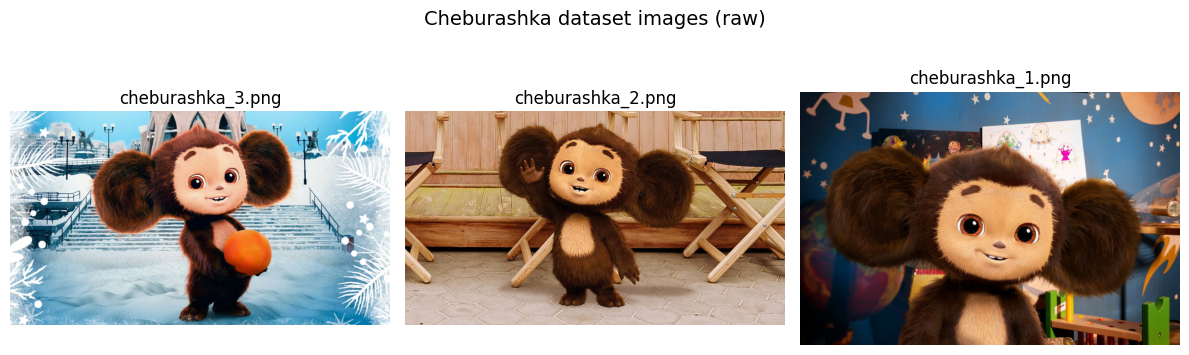

In [6]:
show_images(images_paths, cols=3, title="Cheburashka dataset images (raw)")

Make dataset

In [23]:
class CheburashkaDataset(Dataset):
    def __init__(self, image_paths, size=512):
        self.image_paths = list(image_paths)
        self.size = size

        self.transform = T.Compose([
            T.Resize((size, size), interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = Image.open(p).convert("RGB")
        x = self.transform(img)
        return {
            "pixel_values": x,
            "path": str(p),
        }

In [24]:
ds = CheburashkaDataset(images_paths, size=512)

sample = ds[0]["pixel_values"]
print("sample tensor shape:", sample.shape, "dtype:", sample.dtype, "min/max:", sample.min().item(), sample.max().item())

sample tensor shape: torch.Size([3, 512, 512]) dtype: torch.float32 min/max: -1.0 1.0


Test generating

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 750.26it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /Users/satanislav/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 12.48it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the 

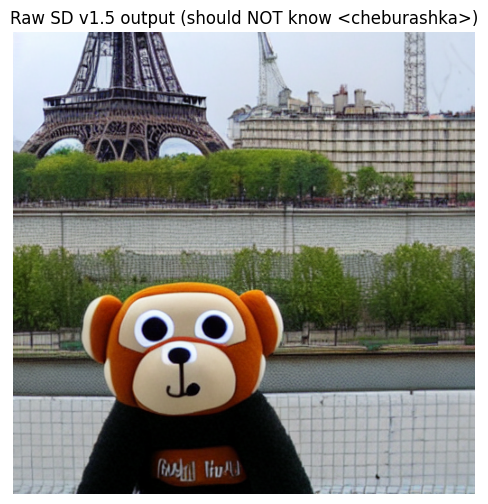

In [7]:
dtype = torch.float16 if DEVICE == "cuda" else torch.float32

pipe = DiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,
    safety_checker=None,
)
pipe = pipe.to(DEVICE)

if hasattr(pipe, "enable_attention_slicing"):
    pipe.enable_attention_slicing()

prompt = "<cheburashka> with the Eiffel Tower in the background"

generator = torch.Generator(device=DEVICE).manual_seed(SEED)

with torch.inference_mode():
    out = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        generator=generator,
    )

img = out.images[0]
plt.figure(figsize=(6, 6))
plt.title("Raw SD v1.5 output (should NOT know <cheburashka>)")
plt.imshow(img)
plt.axis("off")
plt.show()

Text embeds

In [8]:
prompt_for_training = "<cheburashka> plushie"

with torch.inference_mode():
    prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
        prompt=prompt_for_training,
        device=pipe.device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=False,
        negative_prompt=None,
    )

print("prompt_embeds         :", tuple(prompt_embeds.shape), prompt_embeds.dtype, prompt_embeds.device)

torch.save(prompt_embeds.detach().cpu(), emb_path)

prompt_embeds         : (1, 77, 768) torch.float32 cpu


Cleanup

In [11]:
del pipe

In [9]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Further training of the model

train config

In [10]:
@dataclass
class TrainConfig:
    model_id: str = "runwayml/stable-diffusion-v1-5"

    learning_rate: float = 2.0e-5
    max_train_steps: int = 1000
    train_batch_size: int = 1
    max_grad_norm: float = 1.0

    lr_scheduler: str = "constant"
    lr_warmup_steps: int = 0

    snr_gamma: float = 5.0
    lora_rank: int = 128

    checkpoint_every: int = 500
    out_dir: str = lora_path

In [17]:
cfg = TrainConfig()

Load scheduler / UNet / VAE

- VAE is needed to translate images from pixels to latent space (and back).
  UNet is trained to predict noise in the latent space, not in the pixels.
- Scheduler is needed for:
  - sampling t (diffusion time)
  - adding noise to latents based on the selected t (add_noise)
  - determining prediction_type (epsilon/v_prediction) and remembering values.

In [18]:
scheduler = DDPMScheduler.from_pretrained(cfg.model_id, subfolder="scheduler")

vae = AutoencoderKL.from_pretrained(cfg.model_id, subfolder="vae", torch_dtype=DTYPE).to(DEVICE)
unet = UNet2DConditionModel.from_pretrained(cfg.model_id, subfolder="unet", torch_dtype=DTYPE).to(DEVICE)

vae.requires_grad_(False)
unet.requires_grad_(False)

vae.eval()
unet.train()

print("Loaded. prediction_type:", scheduler.config.prediction_type)

/Users/satanislav/Documents/projects/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loaded. prediction_type: epsilon


Add LoRA to UNet 

In [19]:
lora_config = LoraConfig(
    r=cfg.lora_rank,
    lora_alpha=cfg.lora_rank,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

ADAPTER_NAME = "cheburashka"

unet.add_adapter(lora_config, adapter_name=ADAPTER_NAME)
unet.set_adapter(ADAPTER_NAME)

trainable, total = 0, 0
for n, p in unet.named_parameters():
    total += p.numel()
    if p.requires_grad:
        trainable += p.numel()
        
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.4f}%)")

Trainable params: 25,509,888 / 885,030,852 (2.8824%)


Load prompt embeddings 

In [20]:
prompt_embeds = torch.load(emb_path, map_location="cpu").to(device=DEVICE, dtype=DTYPE)

print("prompt_embeds    :", tuple(prompt_embeds.shape), prompt_embeds.dtype, prompt_embeds.device)


prompt_embeds    : (1, 77, 768) torch.float32 cpu


DataLoader

In [25]:
dl = DataLoader(ds, batch_size=cfg.train_batch_size, shuffle=True, num_workers=0, pin_memory=(DEVICE=="cuda"))

Optimizer

In [26]:
trainable_params = [p for p in unet.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=cfg.learning_rate)

def get_lr(step: int) -> float:
    return cfg.learning_rate

print("Trainable tensors:", len(trainable_params))

Trainable tensors: 256


Helpers: SNR weighting (snr_gamma)

In [27]:
def compute_snr(scheduler: DDPMScheduler, timesteps: torch.Tensor) -> torch.Tensor:
    alphas_cumprod = scheduler.alphas_cumprod.to(device=timesteps.device, dtype=torch.float32)
    alpha = alphas_cumprod[timesteps].sqrt()
    sigma = (1.0 - alphas_cumprod[timesteps]).sqrt()
    snr = (alpha / sigma) ** 2
    return snr

def snr_weighted_mse_loss(model_pred, target, timesteps, scheduler, snr_gamma: float):
    loss = F.mse_loss(model_pred.float(), target.float(), reduction="none")
    loss = loss.mean(dim=list(range(1, loss.ndim)))

    if snr_gamma is None or snr_gamma <= 0:
        return loss.mean()

    snr = compute_snr(scheduler, timesteps).to(loss.device)
    gamma = torch.tensor(snr_gamma, device=loss.device, dtype=snr.dtype)
    weights = torch.minimum(snr, gamma) / snr
    return (loss * weights).mean()

Training loop

Explanations for the training steps:

1. Why do we need a VAE:
   Stable Diffusion is trained and operates in latent space, not pixels.
   VAE.encode transforms the image (B,3,512,512) into latents (B,4,64,64) (for SD1.5).
   This accelerates training and improves quality.

2. How the diffusion time t is sampled:
   For each example, choose timestep t uniformly from [0, num_train_timesteps).

3. How the image is noised:
   Sample noise ~ N(0, I), then noisy_latents = scheduler.add_noise(latents, noise, t).

4. What goes to the input of the UNet:
   UNet receives noisy_latents, timestep t, and the text condition encoder_hidden_states (=prompt_embeds).

5. Which loss is considered:
    MSE between the UNet prediction (model_pred) and the target target:
    - if prediction_type == "epsilon": target = noise
    - if prediction_type == "v_prediction": target = scheduler.get_velocity(latents, noise, t)

6. What are the "additions":
    - latents

In [28]:
out_dir = Path(cfg.out_dir)

global_step = 0
loss_history = []

scaling_factor = getattr(vae.config, "scaling_factor", 0.18215)

autocast_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if DEVICE == "cuda" else nullcontext()

In [29]:
def save_checkpoint(step: int):
    ckpt_dir = out_dir / f"step_{step:06d}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    saved = False

    if hasattr(unet, "save_adapter"):
        unet.save_adapter(ckpt_dir, adapter_name=ADAPTER_NAME)
        saved = True

    if not saved:
        try:
            lora_sd = get_peft_model_state_dict(unet)
            torch.save(lora_sd, ckpt_dir / "lora_state_dict.pt")
            saved = True
        except Exception:
            pass

    if not saved:
        unet.save_pretrained(ckpt_dir)
        saved = True

    meta = {
        "step": step,
        "adapter_name": ADAPTER_NAME,
        "lora_rank": cfg.lora_rank,
        "learning_rate": cfg.learning_rate,
        "snr_gamma": cfg.snr_gamma,
        "scaling_factor": float(scaling_factor),
        "prediction_type": scheduler.config.prediction_type,
    }
    torch.save(meta, ckpt_dir / "meta.pt")
    print(f"[checkpoint] saved to: {ckpt_dir}")

In [ ]:
print("Start training...")

unet.train()
for epoch in range(10_000):
    for batch in dl:
        if global_step >= cfg.max_train_steps:
            break

        pixel_values = batch["pixel_values"].to(device=DEVICE, dtype=DTYPE)

        with torch.no_grad():
            latents_dist = vae.encode(pixel_values).latent_dist
            latents = latents_dist.sample()
            latents = latents * scaling_factor

        bsz = latents.shape[0]
        timesteps = torch.randint(
            0, scheduler.config.num_train_timesteps, (bsz,),
            device=DEVICE, dtype=torch.long
        )

        noise = torch.randn_like(latents)
        noisy_latents = scheduler.add_noise(latents, noise, timesteps)

        cond = prompt_embeds
        if cond.shape[0] != bsz:
            cond = cond.repeat(bsz, 1, 1)

        with (torch.autocast("cuda", dtype=torch.float16) if DEVICE == "cuda" else nullcontext()):
            model_out = unet(noisy_latents, timesteps, encoder_hidden_states=cond)
            model_pred = model_out.sample

            if scheduler.config.prediction_type == "epsilon":
                target = noise
            elif scheduler.config.prediction_type == "v_prediction":
                target = scheduler.get_velocity(latents, noise, timesteps)
            else:
                raise ValueError(f"Unknown prediction_type: {scheduler.config.prediction_type}")

            loss = snr_weighted_mse_loss(
                model_pred, target, timesteps, scheduler, snr_gamma=cfg.snr_gamma
            )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        if cfg.max_grad_norm is not None and cfg.max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)

        for pg in optimizer.param_groups:
            pg["lr"] = get_lr(global_step)

        optimizer.step()

        global_step += 1
        loss_history.append(loss.item())

        if global_step % 50 == 0:
            avg = sum(loss_history[-50:]) / 50
            print(f"step {global_step:4d}/{cfg.max_train_steps} | loss {loss.item():.4f} | avg50 {avg:.4f}")

        if global_step % cfg.checkpoint_every == 0:
            save_checkpoint(global_step)

    if global_step >= cfg.max_train_steps:
        break

print("Training finished at step:", global_step)
save_checkpoint(global_step)

## Demonstration of the results

Build generation pipeline 

In [30]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=DTYPE,
    safety_checker=None,
).to(DEVICE)

if hasattr(pipe, "enable_attention_slicing"):
    pipe.enable_attention_slicing()

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 743.23it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /Users/satanislav/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 15.52it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the 

In [31]:
def ensure_lora_attached(unet, rank: int = 128):
    if hasattr(unet, "peft_config") and ADAPTER_NAME in getattr(unet, "peft_config", {}):
        existing_r = getattr(unet.peft_config[ADAPTER_NAME], "r", None)
        if existing_r is not None and existing_r != rank:
            raise ValueError(f"Adapter {ADAPTER_NAME} exists with r={existing_r}, checkpoint expects r={rank}")
        unet.set_adapter(ADAPTER_NAME)
        return

    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank,
        init_lora_weights="gaussian",
        target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    )
    unet.add_adapter(lora_config, adapter_name=ADAPTER_NAME)
    unet.set_adapter(ADAPTER_NAME)

def load_checkpoint_into_unet(unet, ckpt_dir: Path, rank_default: int = 128):
    ckpt_dir = Path(ckpt_dir)
    meta = torch.load(ckpt_dir / "meta.pt", map_location="cpu") if (ckpt_dir / "meta.pt").exists() else {}
    rank = int(meta.get("lora_rank", rank_default))

    if hasattr(unet, "load_adapter") and (ckpt_dir / "adapter_config.json").exists():
        unet.load_adapter(ckpt_dir, adapter_name=ADAPTER_NAME)
        unet.set_adapter(ADAPTER_NAME)
        return {"format": "diffusers_adapter", "rank": rank, "meta": meta}

    lora_sd_path = ckpt_dir / "lora_state_dict.pt"
    if lora_sd_path.exists():
        ensure_lora_attached(unet, rank=rank)
        lora_sd = torch.load(lora_sd_path, map_location="cpu")
        if len(lora_sd) < 50:
            raise ValueError(f"LoRA state dict too small ({len(lora_sd)} keys). Check ADAPTER_NAME / conversion.")
        set_peft_model_state_dict(unet, lora_sd, adapter_name=ADAPTER_NAME)
        unet.set_adapter(ADAPTER_NAME)
        return {"format": "peft_state_dict", "rank": rank, "meta": meta}

In [32]:
PROMPTS = [
    "<cheburashka> with the Eiffel Tower in the background",
    "<cheburashka> plushie",
    "<cheburashka> in sketch style",
    "<cheburashka> riding a bycycle",
]

NEGATIVE = "blurry, lowres, deformed"

def generate_images(pipe, prompts, seed=42, steps=20, guidance=7.5):
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    images = []
    for p in prompts:
        with torch.inference_mode():
            out = pipe(
                p,
                negative_prompt=NEGATIVE,
                num_inference_steps=steps,
                guidance_scale=guidance,
                generator=gen,
            )
        images.append(out.images[0])
    return images

def show_grid(images, titles, cols=2, figsize=(10, 10), suptitle=None):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=figsize)
    if suptitle:
        plt.suptitle(suptitle, fontsize=14)
    for i, (img, t) in enumerate(zip(images, titles)):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [33]:
pick = []
for name in ["step_000500", "step_001000"]:
    p = lora_path / Path(name)
    if p.exists():
        weights_path: Path = lora_path / Path(name) / Path("diffusion_pytorch_model.safetensors")
        sd = load_file(str(weights_path))
        lora_sd = {k: v for k, v in sd.items() if (".lora_A." in k or ".lora_B." in k) and f".{ADAPTER_NAME}." in k}
        conv_path: Path = lora_path / Path(name) / Path("lora_state_dict.pt")
        step_path: Path = lora_path / Path(name)
        torch.save(lora_sd, conv_path)
        pick.append(step_path)

print("Compare checkpoints:", [p.name for p in pick])

Compare checkpoints: ['step_000500', 'step_001000']


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 767.56it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /Users/satanislav/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 16.11it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the 

Loaded: peft_state_dict rank: 128


100%|██████████| 30/30 [01:17<00:00,  2.58s/it]


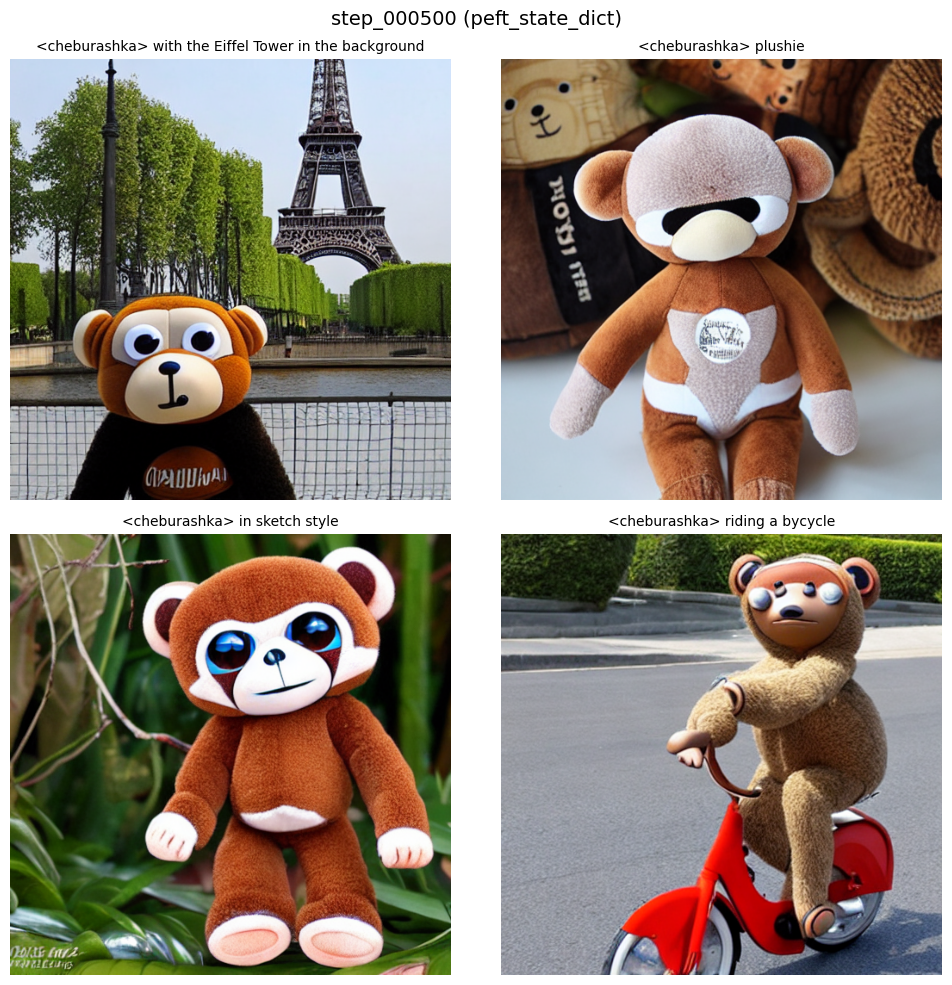

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 848.91it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /Users/satanislav/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 16.23it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the 

Loaded: peft_state_dict rank: 128


100%|██████████| 30/30 [01:19<00:00,  2.65s/it]


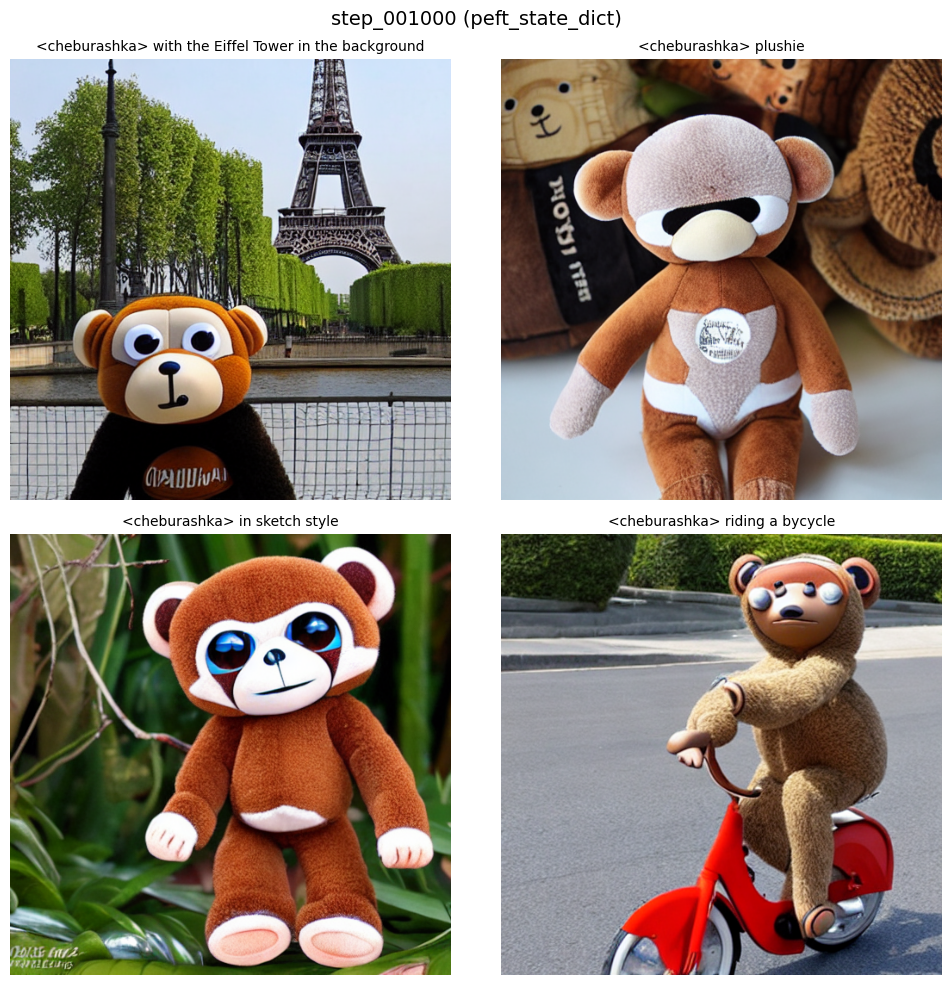

In [36]:
results = {}

for p in pick:
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=DTYPE,
        safety_checker=None,
    ).to(DEVICE)
    
    if hasattr(pipe, "enable_attention_slicing"):
        pipe.enable_attention_slicing()

    info = load_checkpoint_into_unet(pipe.unet, p, rank_default=128)
    print("Loaded:", info["format"], "rank:", info["rank"])

    if hasattr(pipe.unet, "set_adapters"):
        pipe.unet.set_adapters([ADAPTER_NAME], [1.6])

    imgs = generate_images(pipe, PROMPTS, seed=42, steps=30, guidance=7.5)
    results[p.name] = (imgs, info)

    show_grid(imgs, PROMPTS, cols=2, figsize=(10, 10), suptitle=f"{p.name} ({info['format']})")